# Plotting with SymPy: Matplotlib vs GeoGebra (English)

This example shows a compact workflow: define a symbolic expression with SymPy,
sample it numerically with `lambdify` + NumPy, and render the samples with (A)
Matplotlib for static figures and (B) GeoGebra for interactive exploration.

Run cells in order. If you want to use GeoGebra cells, ensure a JupyterLab kernel
is running and that you can open the ggblab GeoGebra panel (see README).

In [2]:
# Imports
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML
# GeoGebra import is used only in GeoGebra cells
from ggblab.ggbapplet import GeoGebra

In [3]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [4]:
plt.style.use('seaborn-v0_8')

In [5]:
# Define symbolic function and numeric sampler
x = sp.symbols('x')
f_expr = sp.sin(x) + 0.2 * x**2
f_num = sp.lambdify(x, f_expr, modules='numpy')

# Sample points (use linspace to ensure endpoints match)
xs = np.linspace(-3, 3, 201)
ys = f_num(xs)
print('Samples:', xs.size)

Samples: 201


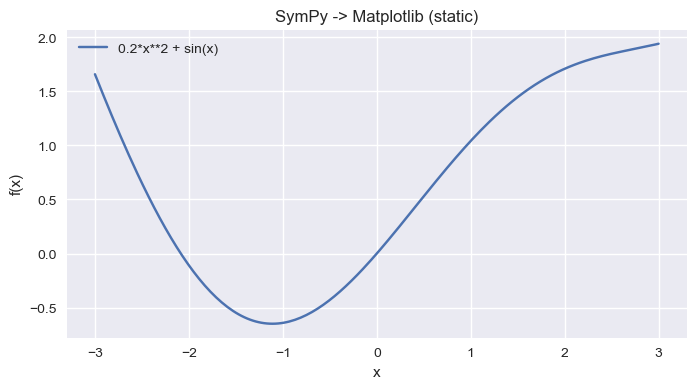

In [6]:
# Matplotlib (static)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(xs, ys, label=str(f_expr))
ax.set_title('SymPy -> Matplotlib (static)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()
plt.show()

## GeoGebra: send samples as two lists and draw LineGraph(xList, yList)

The following cells show how to create two GeoGebra lists (x and y) and call
`LineGraph(xList, yList)`. This is efficient and keeps the applet responsive.
Run these cells only after opening a GeoGebra panel with `ggb.init()`.

In [10]:
# Create helper to send lists to GeoGebra and draw LineGraph
async def send_to_geogebra(ggb, xs, ys, name='data'):
    # Format numeric lists with limited decimal places to reduce payload size
    xs_str = ','.join(f'{float(xi):.6f}' for xi in xs)
    ys_str = ','.join(f'{float(yi):.6f}' for yi in ys)
    await ggb.command(f'{name}_x = {{{xs_str}}}')
    await ggb.command(f'{name}_y = {{{ys_str}}}')
    await ggb.command(f'LineGraph({name}_x, {name}_y)')

In [11]:
# Usage (example, run in separate cells):
ggb = GeoGebra()
await ggb.init()

Using local cached file: xsd/common.xsd


In [12]:
await send_to_geogebra(ggb, xs, ys)

## Capture a GeoGebra screenshot (PNG Base64) and display it in the notebook

GeoGebra can return a PNG as a Base64 string via `getPNGBase64`. The example below
shows how to call the function, decode the Base64 data, and display the PNG inside
the notebook. This is useful for automated reporting or when you cannot open the
live panel in the same UI session.

In [8]:
# Screenshot example (async)
import base64

async def capture_geogebra_png(ggb, scale=1, transparent=True, dpi=72):
    # Call GeoGebra frontend to get PNG as base64 string
    r = await ggb.function('getPNGBase64', [scale, transparent, dpi])
    # r may include a data URI prefix; strip if present
    if isinstance(r, str) and r.startswith('data:image'):
        r = r.split(',', 1)[1]
    img_bytes = base64.b64decode(r)
    display(Image(data=img_bytes, format='png'))
    # # Optionally save to file
    # with open('ggb_screenshot.png', 'wb') as f:
    #     f.write(img_bytes)

# Usage (run in separate cells):
# ggb = GeoGebra()
# await ggb.init()
# await capture_geogebra_png(ggb)

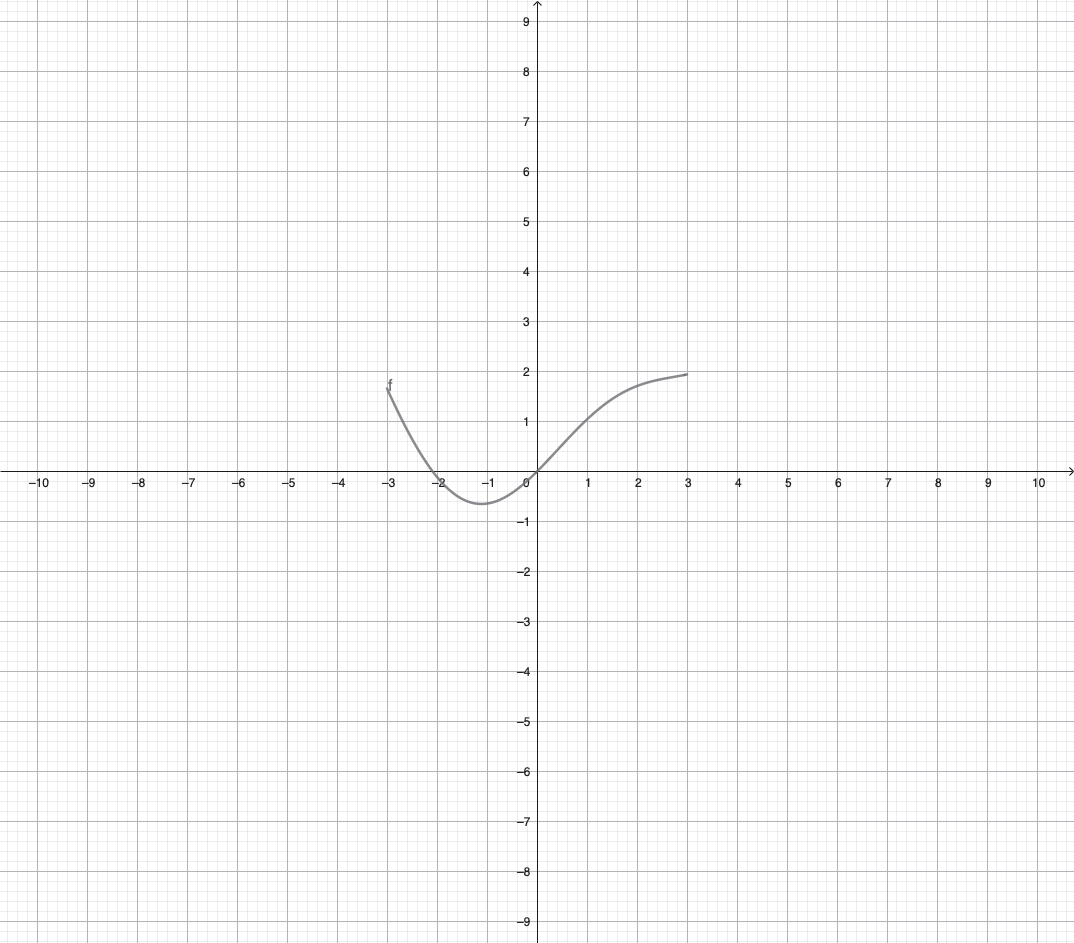

In [13]:
await capture_geogebra_png(ggb)

## Notes and recommendations
- For publication-quality static figures use Matplotlib (high control over styles and export).
- For interactive classroom exploration, GeoGebra provides immediate manipulation and domain-specific tools (constructions, geometric objects, sliders).
- When sending large datasets to GeoGebra, prefer list-based imports or the frontend's bulk APIs (Base64/evalXML/Curve) rather than creating many individual point objects.

If you want, I can add an automated cell that runs the full pipeline (init applet, send data, capture PNG) for a quick demo.